In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric.mplstyle")


In [ ]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
model.eval()

In [5]:
sim_type = model.tokenizer.simulator
dataset_synthetic_short = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(1), num=1000))
dataset_synthetic_long = jax.vmap(simulator[1])(jax.random.split(jax.random.PRNGKey(2), num=1000))

In [6]:
from functools import partial
import jax
import jax.numpy as jnp
data = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(0), 10_000))
data0 = jax.vmap(partial(simulator[0], mask_prior_hyperparameter=jnp.array([0.1])))(jax.random.split(jax.random.PRNGKey(42), 10_000))
data1 = jax.vmap(partial(simulator[0], mask_prior_hyperparameter=jnp.array([0.3])))(jax.random.split(jax.random.PRNGKey(42), 10_000))
data2 = jax.vmap(partial(simulator[0], mask_prior_hyperparameter=jnp.array([0.5])))(jax.random.split(jax.random.PRNGKey(43), 10_000))
data3 = jax.vmap(partial(simulator[0], mask_prior_hyperparameter=jnp.array([0.8])))(jax.random.split(jax.random.PRNGKey(44), 10_000))

In [6]:
nnx.display(model)

In [7]:
import jax
import jax.numpy as jnp

def log_prob_pit(data, rng, n=200):
    """
    Continuous randomized PIT from log-prob scores.

    Returns a PIT value in (0,1) that should be Uniform(0,1) under self-consistency / SBC.
    """
    rng_samp, rng_tie, rng_jit = jax.random.split(rng, 3)

    # Sample masks
    keys = jax.random.split(rng_samp, n)
    sample_fn = lambda k: model.sample_mask(
        k, acq=data["acq"], x=data["x"], mask_prior=data["mask_prior"]
    )
    masks = jax.vmap(sample_fn)(keys)

    # Log probs (force scalar)
    logprob_fn = lambda m: model.log_prob_mask(
        m, acq=data["acq"], x=data["x"], mask_prior=data["mask_prior"]
    )

    lp_true = jnp.reshape(logprob_fn(data["model_mask"]), (-1,)).sum()

    lp_samp = jax.vmap(logprob_fn)(masks)
    lp_samp = jnp.reshape(lp_samp, (n, -1)).sum(axis=1)  # shape (n,)

    # Randomized rank with tie-breaking
    eq = jnp.isclose(lp_samp, lp_true, rtol=1e-4, atol=1e-4)  # tune tolerances
    lt = (lp_samp < lp_true) & (~eq)

    n_lt = jnp.sum(lt)
    n_eq = jnp.sum(eq)

    tie = jax.random.randint(rng_tie, (), 0, n_eq + 1)   # integer in {0,...,n_eq}
    r = n_lt + tie                                       # integer rank in {0,...,n}

    # Continuous jitter within the rank cell to avoid histogram/binning artefacts
    v = jax.random.uniform(rng_jit, (), minval=0.0, maxval=1.0)
    pit = (r + v) / (n + 1)                              # in (0,1)

    return pit


def expected_coverage(data, rng, n=1000):
    """
    Returns:
      alpha: (K,) nominal levels in [0,1]
      coverage: (K,) empirical CDF of PITs, should track diagonal if calibrated
      pits: (B,) PIT values
    """
    B = data["x"].shape[0]
    keys = jax.random.split(rng, B)

    # Map across batch; data is assumed to be a pytree with leading dimension B
    pits = jax.lax.map(
        lambda args: log_prob_pit(*args, n=n),
        (data, keys),
        batch_size=100
    )

    alpha = jnp.linspace(0.0, 1.0, 101)
    coverage = jnp.mean(pits[:, None] <= alpha[None, :], axis=0)
    return alpha, coverage, pits


In [8]:
coverage = expected_coverage(data, jax.random.PRNGKey(0))
coverage0 = expected_coverage(data0, jax.random.PRNGKey(42))
coverage1 = expected_coverage(data1, jax.random.PRNGKey(0))
coverage2 = expected_coverage(data2, jax.random.PRNGKey(1))
coverage3 = expected_coverage(data3, jax.random.PRNGKey(2))

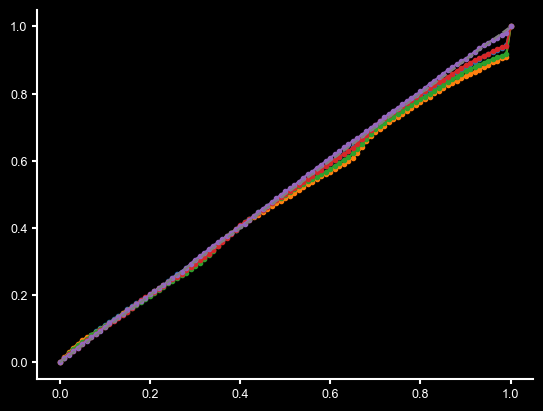

In [9]:
import matplotlib.pyplot as plt
plt.plot(coverage[0], coverage[1], marker='o', label='Overall')
plt.plot(coverage0[0], coverage0[1], marker='o')
plt.plot(coverage1[0], coverage1[1], marker='o')
plt.plot(coverage2[0], coverage2[1], marker='o')
plt.plot(coverage3[0], coverage3[1], marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color ='gray')

In [7]:
from dmri.eval.load_data import load_and_process_data
from dmri.simulators.acquisition_scheme import acquisition_scheme
path = "../data/data"
data, data_norm, brain_mask, bvals, bvecs = load_and_process_data(path, "nodif_brain_mask.nii.gz", "data.nii.gz", "bvals", "bvecs")
acq = acquisition_scheme(bvals,bvecs)

full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)
acq = acquisition_scheme(bvals, bvecs)
full_data_flat_in_brain = full_data_flat[brain_mask_flat, :]
full_data_flat_in_brain = np.nan_to_num(
    full_data_flat_in_brain, nan=0.0, posinf=0.0, neginf=0.0
)
exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)


/weka/macke/mgloeckler90/dmri/dmri/eval/load_data.py:57: RuntimeWarning: divide by zero encountered in divide
  data_norm = data_norm / S0
/weka/macke/mgloeckler90/dmri/dmri/eval/load_data.py:57: RuntimeWarning: invalid value encountered in divide
  data_norm = data_norm / S0


In [71]:
# Sample masks whole brain ALL
p_prior = 1.

masksall = [
    jnp.array([True]*1 + [False]*9), # Ball
    jnp.array([True]*2 + [False]*8), # Ball + 1 Stick
    jnp.array([True]*3 + [False]*7), # Ball + 2 Sticks
    jnp.array([True]*4 + [False]*6), # Ball + 3 Sticks
    jnp.array([True] + [False]*3 + [True]*1 + [False]*5), # Ball + Zeppelin
    jnp.array([True] + [False]*3 + [True]*2 + [False]*4), # Ball + 2 Zeppelins
    jnp.array([True] + [False]*3 + [True]*3 + [False]*3), # Ball + 3 Zeppelins
    jnp.array([True] + [False]*6 + [True, False, False]), # One Tensor
    jnp.array([True] + [False]*6 + [True, True, False]), # Two Tensors
    jnp.array([True] + [False]*6 + [True, True, True]), # Three Tensors
]

def sample_mask_per_x(key, x):
    log_probs = []
    for mask in masksall:
        key, subkey = jax.random.split(key)
        mask = jnp.concatenate([mask, jnp.array([False, True])], axis=0)
        log_probs.append(model.log_prob_mask(mask, acq, x, jnp.array([p_prior])))
    log_probs = jnp.stack(log_probs, axis=-1)
    return log_probs

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


batch_size = 10_000
key = jax.random.key(0)
probs_brain_01 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_01.append(batch_masks)
probs_brain_01 = np.concatenate(probs_brain_01, axis=0)


Batch 0
Batch 10000
Batch 20000
Batch 30000
Batch 40000
Batch 50000
Batch 60000
Batch 70000
Batch 80000
Batch 90000
Batch 100000
Batch 110000
Batch 120000
Batch 130000
Batch 140000
Batch 150000
Batch 160000
Batch 170000
Batch 180000
Batch 190000
Batch 200000
Batch 210000
Batch 220000


In [21]:
from dmri.utils.viz import orthoview_ultracompact, save_orthoview_html
labels_preselected = [mask_to_label(mask) for mask in masksall]
indexed_models_text = ""
for i, label in enumerate(labels_preselected):
    indexed_models_text += f"{i}: {label}\n"
full_probs01_in_brain = np.zeros((data_norm.shape[:-1]) + (10,))

full_probs01_in_brain[brain_mask.astype(bool), :] = jax.nn.softmax(probs_brain_01, axis=-1)

# Sample masks whole brain
model_selected01 = np.argmax(full_probs01_in_brain, axis=-1)
fig = orthoview_ultracompact(model_selected01, width=1200, height=800)
fig.add_annotation(
    x=0,              # or normalized coordinates, see below
    y=1,
    text="Model selection (preselected subset, no parameter penalty)",
    showarrow=False,
    font=dict(size=20, color="white"),
    xref="paper",      # use figure coordinates instead of data coords
    yref="paper"
)
fig.add_annotation(
    x=0,              # or normalized coordinates, see below
    y=0.95,
    text=indexed_models_text,
    showarrow=False,
    font=dict(size=12, color="white"),
    xref="paper",      # use figure coordinates instead of data coords
    yref="paper"
)
#save_orthoview_html(fig, "model_selection_all_gauss_no_penalty.html")
fig.show()


In [8]:
p_prior = 1.0
from functools import partial

def sample_masks(key, x):
    sample_fn = partial(model.sample_mask, acq=acq, x=x, mask_prior=jnp.array([p_prior]))
    masks = jax.vmap(sample_fn)(jax.random.split(key, 50))
    log_probs = jax.vmap(partial(model.log_prob_mask, acq=acq, x=x, mask_prior=jnp.array([p_prior])))(masks)
    idx = jnp.argmax(log_probs)
    masks = masks[idx]
    return masks

sample_mask_per_x = jax.jit(jax.vmap(sample_masks, in_axes=(0,0)))


batch_size = 5_000
key = jax.random.key(0)
samples_in_brain = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    samples_in_brain.append(batch_masks)
samples_in_brain = np.concatenate(samples_in_brain, axis=0)


Batch 0


Batch 5000
Batch 10000
Batch 15000
Batch 20000
Batch 25000
Batch 30000
Batch 35000
Batch 40000
Batch 45000
Batch 50000
Batch 55000
Batch 60000
Batch 65000
Batch 70000
Batch 75000
Batch 80000
Batch 85000
Batch 90000
Batch 95000
Batch 100000
Batch 105000
Batch 110000
Batch 115000
Batch 120000
Batch 125000
Batch 130000
Batch 135000
Batch 140000
Batch 145000
Batch 150000
Batch 155000
Batch 160000
Batch 165000
Batch 170000
Batch 175000
Batch 180000
Batch 185000
Batch 190000
Batch 195000
Batch 200000
Batch 205000
Batch 210000
Batch 215000
Batch 220000
Batch 225000


In [13]:
from dmri.eval.export_theta import embed_in_full_brain_array
from dmri.utils.dmriutils import export_nifti

map_models = embed_in_full_brain_array(samples_in_brain, brain_mask.reshape(-1), data.shape[:-1])
export_nifti(map_models.astype(float),data, ".", f"model_map_all_prior_{p_prior}.nii.gz")

In [24]:
labels_per_voxel = [mask_to_label(samples_in_brain[i,:-2]) for i in range(samples_in_brain.shape[0])]

In [26]:
comb, counts = np.unique(labels_per_voxel, return_counts=True)
idx = np.argsort(-counts)
comb = comb[idx]
counts = counts[idx]

In [15]:
def mask_to_label(mask):
    model_types = sim_type.model_types
    name = ""
    for i,m in enumerate(mask):
        if i >= len(model_types):
            continue
        if m:
            name += str(model_types[i]).split(".")[-1].replace("'","")

    return name[:-1]

In [30]:
top10 = comb[:10]
top10

array(['Ball>Zeppelin>Dti', 'Ball>Zeppelin>Zeppelin',
       'Ball>Zeppelin>Zeppelin>Zeppelin', 'Ball>Zeppelin',
       'Ball>Zeppelin>Dti>Dti', 'Zeppelin>Zeppelin',
       'Ball>Stick>Zeppelin', 'Ball>Zeppelin>Zeppelin>Dti',
       'Ball>Zeppelin>Dti>Dti>Dti', 'Ball>Zeppelin>Zeppelin>Zeppelin>Dti'],
      dtype='<U61')

In [36]:
counts[:10].sum()

np.int64(130826)

In [47]:
top10_maskref = []
for top in top10:
    for i, ref in enumerate(labels_per_voxel):
        if ref == top:
            top10_maskref.append(samples_in_brain[i])
            break

In [60]:
top10_dof = []
for mask in top10_maskref:
    dof = int(mask.sum(-1) - 2)
    for m_type,m in zip(sim_type.model_types, mask):
        dof += int(m_type.theta_dim * m)
    top10_dof.append(dof)

In [63]:
top10_dof

[13, 11, 16, 6, 20, 9, 10, 18, 27, 23]

In [65]:
import pandas as pd
df = pd.DataFrame({
    "Model": top10,
    "Count": counts[:10],
    "Mask": [list(m) for m in top10_maskref],
    "DOF": top10_dof
})

df

,Model,Count,Mask,DOF
0,Ball>Zeppelin>Dti,34770,"[True, False, False, False, False, True, False...",13
1,Ball>Zeppelin>Zeppelin,18445,"[True, False, False, False, True, False, True,...",11
2,Ball>Zeppelin>Zeppelin>Zeppelin,17565,"[True, False, False, False, True, True, True, ...",16
3,Ball>Zeppelin,11603,"[True, False, False, False, True, False, False...",6
4,Ball>Zeppelin>Dti>Dti,10646,"[True, False, False, False, True, False, False...",20
5,Zeppelin>Zeppelin,9188,"[False, False, False, False, True, False, True...",9
6,Ball>Stick>Zeppelin,8267,"[True, False, True, False, False, False, True,...",10
7,Ball>Zeppelin>Zeppelin>Dti,7710,"[True, False, False, False, False, True, True,...",18
8,Ball>Zeppelin>Dti>Dti>Dti,6619,"[True, False, False, False, True, False, False...",27
9,Ball>Zeppelin>Zeppelin>Zeppelin>Dti,6013,"[True, False, False, False, True, True, True, ...",23


In [70]:
df.to_csv(f"top10_models_summary_{p_prior}.csv", index=False)

In [49]:
# Sample masks whole brain ALL

masksall = jnp.stack(top10_maskref)

def sample_mask_per_x(key, x):
    log_probs = []
    for mask in masksall:
        key, subkey = jax.random.split(key)
        log_probs.append(model.log_prob_mask(mask, acq, x, jnp.array([p_prior])))
    log_probs = jnp.stack(log_probs, axis=-1)
    return log_probs

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


batch_size = 10_000
key = jax.random.key(0)
probs_brain_01 = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    probs_brain_01.append(batch_masks)
probs_brain_01 = np.concatenate(probs_brain_01, axis=0)


Batch 0
Batch 10000
Batch 20000
Batch 30000
Batch 40000
Batch 50000
Batch 60000
Batch 70000
Batch 80000
Batch 90000
Batch 100000
Batch 110000
Batch 120000
Batch 130000
Batch 140000
Batch 150000
Batch 160000
Batch 170000
Batch 180000
Batch 190000
Batch 200000
Batch 210000
Batch 220000


In [53]:

full_probs01_in_brain = np.zeros((data_norm.shape[:-1]) + (10,))

full_probs01_in_brain[brain_mask.astype(bool), :] = jax.nn.softmax(probs_brain_01, axis=-1)


In [69]:
export_nifti(full_probs01_in_brain.astype(float),data, ".", f"model_probs_top10_prior_{p_prior}.nii.gz")

In [61]:
fig = orthoview_ultracompact(full_probs01_in_brain, vmin=0., vmax=0.5, channel_names=top10, width=1000)
#fig.show()